<a href="https://colab.research.google.com/github/siinwook/ResNet-CIFAR10-from-Scratch/blob/main/ResNet_CIFAR10_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**ResNet**

In [ ]:
import torch
import matplotlib.pyplot as plt

##Cuda

In [ ]:
if torch.cuda.is_available:
  device = 'cuda'
else:
  device = 'cpu'
print(f"device: {device}")

##CIFAR10

In [ ]:
from torchvision.datasets import CIFAR10
from torchvision.transforms import v2
from torch.utils.data import Dataset,DataLoader

#CIFAR10 download mirror server
#CIFAR10.url = "https://data.brainchip.com/dataset-mirror/cifar10/cifar-10-python.tar.gz"

train_transform = v2.Compose([
    #data augmentation
    v2.RandomCrop(32,padding=4),
    v2.RandomHorizontalFlip(),
    v2.ColorJitter(0.4,0.4,0.4,0.1), #Brightness, ...
    v2.RandomGrayscale(0.2), #RGB -> Gray
    v2.ToTensor()
])

test_transform = v2.Compose([
    v2.ToTensor()
])

train_dataset = CIFAR10(
    root = './data',
    train = True,
    transform= train_transform,
    download = True
)

test_dataset = CIFAR10(
    root = './data',
    train = False,
    transform= test_transform,
    download = True
)

In [ ]:
train_dataloader = DataLoader(train_dataset,batch_size=128,shuffle=True)
test_dataloader = DataLoader(test_dataset,batch_size=128,shuffle=False)

##ResNet with skip connection

In [ ]:
from torch.nn.modules.container import ModuleDict
from torch import nn
import torch.nn.init as init

class ResNet(nn.Module):
  """
  Predict 3*32*32 CIFAR10 dataset
  Residual architecture implementation (same architecture with the paper)
  Using Option B (extra parameters only for matching dimensions when filter size changes)
  Identity mapping occurs every 2 Conv
  Conv * (2N+1) (3*3 kernel, filter size = 16) -
  Conv * 2N (3*3 kernel, filter size = 32) -
  Conv * 2N (3*3 kernel, filter size = 64) -
  Average pooling - FC
  """
  def __init__(self,N):
    super().__init__()
    self.N = N
    filter_size = 16

    self.Pre = nn.Sequential(
      nn.Conv2d(3,16,(3,3),padding=1,bias=False),
      nn.BatchNorm2d(filter_size),
      nn.ReLU()
    )

    module_dict={}
    for i in range(1,4):
      for n in range(1,self.N*2+1):
        if i!=1 and n==1: # halve feature map size
          module_dict[f"Change_Dim{i}"] = nn.Sequential(
            nn.Conv2d(filter_size,filter_size*2,(1,1),stride=2,bias=False),
            nn.BatchNorm2d(filter_size*2)
          )
          module_dict[f"Conv{i}_{n}"] = nn.Conv2d(filter_size,filter_size*2,(3,3),stride=2,padding=1,bias=False)
          filter_size*=2
        else:
          module_dict[f"Conv{i}_{n}"] = nn.Conv2d(filter_size,filter_size,(3,3),stride=1,padding=1,bias=False)
        module_dict[f"Batchnorm{i}_{n}"] = nn.BatchNorm2d(filter_size)
        module_dict[f"ReLU{i}_{n}"] = nn.ReLU()

    module_dict["Avgpool"] = nn.AdaptiveAvgPool2d((1,1))
    module_dict["Flatten"] = nn.Flatten()
    module_dict["FC"] = nn.Linear(64,10)

    self.ModuleDict = nn.ModuleDict(module_dict)

  def forward(self,x):
    x = self.Pre(x)
    for i in range(1,4):
      for n in range(1,self.N*2+1,2):
        y = self.ModuleDict[f"Conv{i}_{n}"](x)
        y = self.ModuleDict[f"Batchnorm{i}_{n}"](y)
        y = self.ModuleDict[f"ReLU{i}_{n}"](y)

        y = self.ModuleDict[f"Conv{i}_{n+1}"](y)
        y = self.ModuleDict[f"Batchnorm{i}_{n+1}"](y)
        if i!=1 and n==1:
          x = self.ModuleDict[f"Change_Dim{i}"](x)
        x = self.ModuleDict[f"ReLU{i}_{n+1}"](y+x)

    x = self.ModuleDict["Avgpool"](x)
    x = self.ModuleDict["Flatten"](x)
    x = self.ModuleDict["FC"](x)

    return x

##Plain network with no skip connection

In [ ]:
from torch.nn.modules.container import ModuleDict
from torch import nn
import torch.nn.init as init

class PlainNet(nn.Module):
  """
  Predict 3*32*32 CIFAR10 dataset
  Same architecture to ResNet except skip connection
  Conv * (2N+1) (3*3 kernel, filter size = 16) -
  Conv * 2N (3*3 kernel, filter size = 32) -
  Conv * 2N (3*3 kernel, filter size = 64) -
  Average pooling - FC
  """
  def __init__(self,N):
    super().__init__()
    self.N = N
    filter_size = 16

    self.Pre = nn.Sequential(
      nn.Conv2d(3,16,(3,3),padding=1,bias=False),
      nn.BatchNorm2d(filter_size),
      nn.ReLU()
    )

    module_dict={}
    for i in range(1,4):
      for n in range(1,self.N*2+1):
        if i!=1 and n==1: # halve feature map size
          #module_dict[f"Change_Dim{i}"] = nn.Sequential(
          #  nn.Conv2d(filter_size,filter_size*2,(1,1),stride=2,bias=False),
          #  nn.BatchNorm2d(filter_size*2)
          #)
          module_dict[f"Conv{i}_{n}"] = nn.Conv2d(filter_size,filter_size*2,(3,3),stride=2,padding=1,bias=False)
          filter_size*=2
        else:
          module_dict[f"Conv{i}_{n}"] = nn.Conv2d(filter_size,filter_size,(3,3),stride=1,padding=1,bias=False)
        module_dict[f"Batchnorm{i}_{n}"] = nn.BatchNorm2d(filter_size)
        module_dict[f"ReLU{i}_{n}"] = nn.ReLU()

    module_dict["Avgpool"] = nn.AdaptiveAvgPool2d((1,1))
    module_dict["Flatten"] = nn.Flatten()
    module_dict["FC"] = nn.Linear(64,10)

    self.ModuleDict = nn.ModuleDict(module_dict)

  def forward(self,x):
    x = self.Pre(x)
    for i in range(1,4):
      for n in range(1,self.N*2+1,2):
        y = self.ModuleDict[f"Conv{i}_{n}"](x)
        y = self.ModuleDict[f"Batchnorm{i}_{n}"](y)
        y = self.ModuleDict[f"ReLU{i}_{n}"](y)

        y = self.ModuleDict[f"Conv{i}_{n+1}"](y)
        y = self.ModuleDict[f"Batchnorm{i}_{n+1}"](y)
        #if i!=1 and n==1:
          #x = self.ModuleDict[f"Change_Dim{i}"](x)
        #x = self.ModuleDict[f"ReLU{i}_{n+1}"](y+x)
        x = self.ModuleDict[f"ReLU{i}_{n+1}"](y)

    x = self.ModuleDict["Avgpool"](x)
    x = self.ModuleDict["Flatten"](x)
    x = self.ModuleDict["FC"](x)

    return x

##Weight initialization

In [ ]:
def init_weights(m):
    if isinstance(m, nn.Conv2d):
        # Kaiming Normal (He Normal)
        init.kaiming_normal_(m.weight,mode="fan_in", nonlinearity='relu')
        if m.bias is not None:
            init.constant_(m.bias, 0)
    elif isinstance(m, nn.Linear):
        # Kaiming Normal (He Normal)
        init.kaiming_normal_(m.weight,mode="fan_in", nonlinearity='relu')
        if m.bias is not None:
            init.constant_(m.bias, 0)
    elif isinstance(m, nn.BatchNorm2d):
        init.constant_(m.weight, 1)
        init.constant_(m.bias, 0)

##Training with CIFAR10

In [ ]:
ResNet44=ResNet(N=7).to(device)
ResNet44.apply(init_weights)
#PlainNet44=PlainNet(N=7).to(device)
#PlainNet44.apply(init_weights)

model = ResNet44
#model = PlainNet44

In [ ]:
def train_loop(dataloader,model,train_acc_list=[], train_loss_list=[]):
  model.train()

  current=0
  size = len(dataloader.dataset)
  for batch, (x_train,y_train) in enumerate(iter(dataloader)):
    x_train,y_train = x_train.to(device),y_train.to(device)
    logits = model(x_train)

    optimizer.zero_grad()
    loss = loss_fn(logits,y_train)
    loss.backward()
    optimizer.step()

    current += (logits.argmax(dim=1) == y_train).sum()

  train_acc = current/size
  print(f"train accuracy: {train_acc} / train loss: {loss.item()} ")
  train_acc_list.append(train_acc.item())
  train_loss_list.append(loss.item())

def test_loop(dataloader,model,test_acc_list=[]):
  model.eval()

  current=0
  size = len(dataloader.dataset)
  for batch, (x_test,y_test) in enumerate(iter(dataloader)):
    x_test,y_test = x_test.to(device),y_test.to(device)

    with torch.no_grad():
      logits = model(x_test)
      current += (logits.argmax(dim=1) == y_test).sum()
  test_acc = current/size
  print(f"test accuracy: {test_acc}")
  test_acc_list.append(test_acc.item())


In [ ]:
Res_train_acc_list = []
Res_test_acc_list = []
Res_train_loss_list = []

#Plain_train_acc_list = []
#Plain_test_acc_list = []
#Plain_train_loss_list = []

In [ ]:
loss_fn = nn.CrossEntropyLoss()
lr = 1e-3
weight_decay = 1e-4
optimizer = torch.optim.Adam(model.parameters(),lr=lr,weight_decay = weight_decay)
epochs = 50

for epoch in range(epochs):
  print(f"-----epoch {epoch+1}-----")
  train_loop(train_dataloader,model,Res_train_acc_list,Res_train_loss_list)
  test_loop(test_dataloader,model,Res_test_acc_list)

  #train_loop(train_dataloader,model,Plain_train_acc_list,Plain_train_loss_list)
  #test_loop(test_dataloader,model,Plain_test_acc_list)

##Comparison 1: Parameter Count and Estimated Memory Usage

In [ ]:
# =========================
# Compare the number of parameter and memory complexity
# =========================

from torchsummary import summary

In [ ]:
summary(ResNet44,input_size=(3,32,32),batch_size=128)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [128, 16, 32, 32]             432
       BatchNorm2d-2          [128, 16, 32, 32]              32
              ReLU-3          [128, 16, 32, 32]               0
            Conv2d-4          [128, 16, 32, 32]           2,304
       BatchNorm2d-5          [128, 16, 32, 32]              32
              ReLU-6          [128, 16, 32, 32]               0
            Conv2d-7          [128, 16, 32, 32]           2,304
       BatchNorm2d-8          [128, 16, 32, 32]              32
              ReLU-9          [128, 16, 32, 32]               0
           Conv2d-10          [128, 16, 32, 32]           2,304
      BatchNorm2d-11          [128, 16, 32, 32]              32
             ReLU-12          [128, 16, 32, 32]               0
           Conv2d-13          [128, 16, 32, 32]           2,304
      BatchNorm2d-14          [128, 16,

In [ ]:
summary(PlainNet44,input_size=(3,32,32),batch_size=128)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [128, 16, 32, 32]             432
       BatchNorm2d-2          [128, 16, 32, 32]              32
              ReLU-3          [128, 16, 32, 32]               0
            Conv2d-4          [128, 16, 32, 32]           2,304
       BatchNorm2d-5          [128, 16, 32, 32]              32
              ReLU-6          [128, 16, 32, 32]               0
            Conv2d-7          [128, 16, 32, 32]           2,304
       BatchNorm2d-8          [128, 16, 32, 32]              32
              ReLU-9          [128, 16, 32, 32]               0
           Conv2d-10          [128, 16, 32, 32]           2,304
      BatchNorm2d-11          [128, 16, 32, 32]              32
             ReLU-12          [128, 16, 32, 32]               0
           Conv2d-13          [128, 16, 32, 32]           2,304
      BatchNorm2d-14          [128, 16,

-> Almost same number of parameter(0.65 ~ 0.66M) with negligible difference (Option B)

##Comparison 2 : Performance and Training Difficulty







Dataset: CIFAR-10

Optimizer: Adam(1-35 epoch) / SGD(36-50 epoch)

Learning rate: 0.001(1-20 epoch) / 0.0001(21-50 epoch)

Batch size: 128

Epochs: 50

Data augmentation: Random crop, Horizontal flip, Color jitter, Gray scale

Weight decay: 0.001

Device: cuda

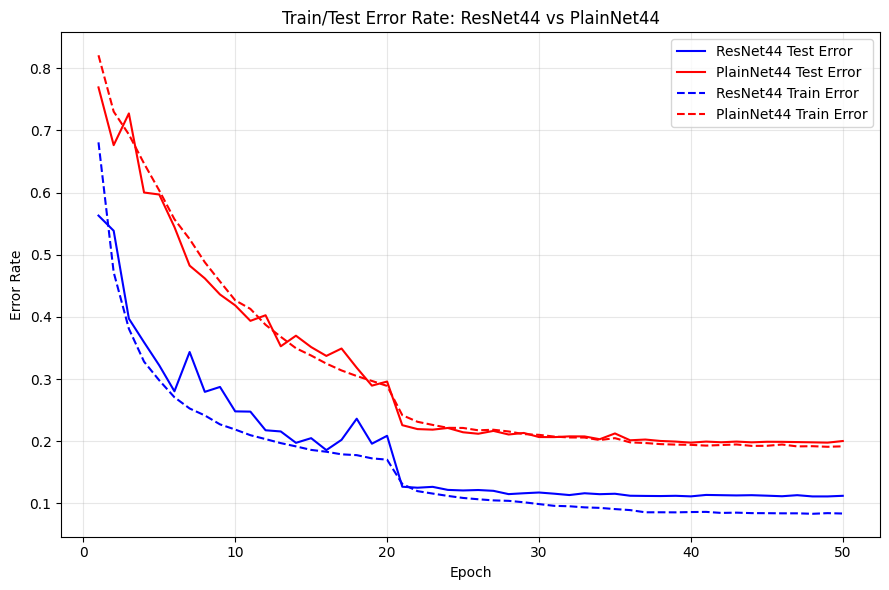

In [ ]:
# =========================
# Compare train/test error rates of ResNet44 and PlainNet44
# =========================

def to_cpu_list(acc_list):
    if isinstance(acc_list, torch.Tensor):
        return acc_list.detach().cpu().tolist()

    return [
        x.detach().cpu().item() if isinstance(x, torch.Tensor) else float(x)
        for x in acc_list
    ]

def acc_to_error_rate(acc_list):
    acc_list = to_cpu_list(acc_list)
    return [1.0 - acc for acc in acc_list]


Res_train_error_list = acc_to_error_rate(Res_train_acc_list)
Res_test_error_list  = acc_to_error_rate(Res_test_acc_list)

Plain_train_error_list = acc_to_error_rate(Plain_train_acc_list)
Plain_test_error_list  = acc_to_error_rate(Plain_test_acc_list)

epochs = range(1, len(Res_train_error_list) + 1)

plt.figure(figsize=(9, 6))

# test: solid
plt.plot(epochs, Res_test_error_list, "b-", label="ResNet44 Test Error")
plt.plot(epochs, Plain_test_error_list, "r-", label="PlainNet44 Test Error")

# train: dot
plt.plot(epochs, Res_train_error_list, "b--", label="ResNet44 Train Error")
plt.plot(epochs, Plain_train_error_list, "r--", label="PlainNet44 Train Error")

plt.xlabel("Epoch")
plt.ylabel("Error Rate")
plt.title("Train/Test Error Rate: ResNet44 vs PlainNet44")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Obervation: ResNet44 gains more accuracy(by 9.0%) and converges earlier than PlainNet44

Interpretation: Deep neural network with residual architecture is easier to optimize

##Comparison 3 : The Degradation Problem

In [ ]:
# =========================
# Compare train/test error rate of shallower network with its deeper counterpart's (20-depth vs 56-depth)
# Training condition is same with Comparison 2
# =========================

ResNet20 = ResNet(N=3).to(device)
#ResNet56 = ResNet(N=9).to(device)
#PlainNet20 = PlainNet(N=3).to(device)
#PlainNet56 = PlainNet(N=9).to(device)

ResNet20.apply(init_weights)
#ResNet56.apply(init_weights)
#PlainNet20.apply(init_weights)
#PlainNet56.apply(init_weights)

model = ResNet20

In [ ]:
ResNet20_train_acc_list = []
#ResNet56_train_acc_list = []
ResNet20_test_acc_list = []
#ResNet56_test_acc_list = []
#PlainNet20_train_acc_list = []
#PlainNet56_train_acc_list = []
#PlainNet20_test_acc_list = []
#PlainNet56_test_acc_list = []

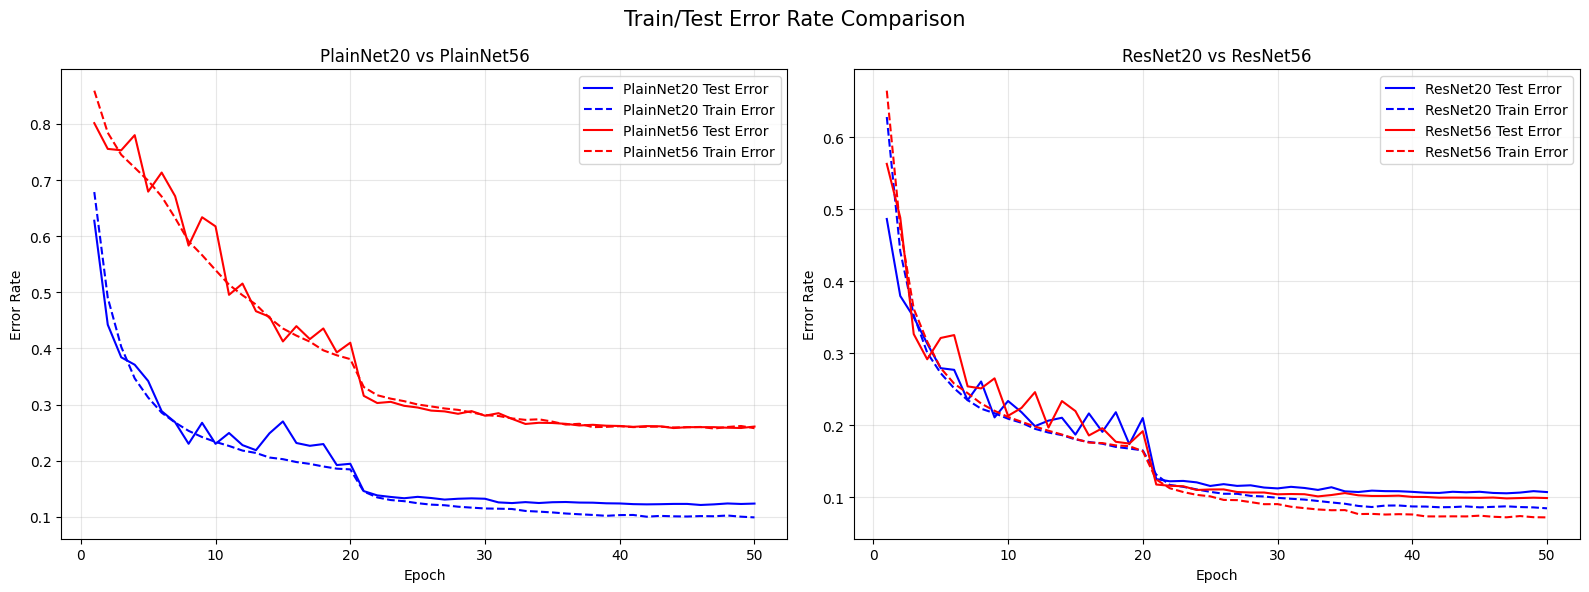

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# =========================
# PlainNet20 vs PlainNet56
# =========================
ax = axes[0]

epochs_plain = range(1, len(PlainNet20_train_error_list) + 1)

ax.plot(
    epochs_plain,
    PlainNet20_test_error_list,
    "b-",
    label="PlainNet20 Test Error"
)
ax.plot(
    epochs_plain,
    PlainNet20_train_error_list,
    "b--",
    label="PlainNet20 Train Error"
)

ax.plot(
    epochs_plain,
    PlainNet56_test_error_list,
    "r-",
    label="PlainNet56 Test Error"
)
ax.plot(
    epochs_plain,
    PlainNet56_train_error_list,
    "r--",
    label="PlainNet56 Train Error"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Error Rate")
ax.set_title("PlainNet20 vs PlainNet56")
ax.grid(True, alpha=0.3)
ax.legend()


# =====================
# ResNet20 vs ResNet56
# =====================
ax = axes[1]

epochs_res = range(1, len(ResNet20_train_error_list) + 1)

ax.plot(
    epochs_res,
    ResNet20_test_error_list,
    "b-",
    label="ResNet20 Test Error"
)
ax.plot(
    epochs_res,
    ResNet20_train_error_list,
    "b--",
    label="ResNet20 Train Error"
)

ax.plot(
    epochs_res,
    ResNet56_test_error_list,
    "r-",
    label="ResNet56 Test Error"
)
ax.plot(
    epochs_res,
    ResNet56_train_error_list,
    "r--",
    label="ResNet56 Train Error"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Error Rate")
ax.set_title("ResNet20 vs ResNet56")
ax.grid(True, alpha=0.3)
ax.legend()


fig.suptitle("Train/Test Error Rate Comparison", fontsize=15)
plt.tight_layout()
plt.show()

Obervation:

1. Plain network gains seriously lower accuracy when layer gets deeper(20 to 56 depth).
2. Residual network even gains slightly more accuracy when layer gets deeper(20 to 56 depth).
3. Considering shallower depth(20-depth), ResNet20 converges faster than PlainNet20 and gains more accuracy(by 2.0%).
4. Considering deeper depth(56-depth), ResNet56 converges much faster than PlainNet56 and gains a far more accuracy(by 16.0%).  

Interpretation:
1. Plain network suffers from *the degradation problem*(accuracy satured at some specific depth and decrease seriously), this phenomena occurs due to neither overfitting(no train/test accuracy gap) nor vanishing gradients(BN)
2. Residual network addresses *the degradation problem* .

Conclusion: Deep residual network with skip connection **addresses the degradation problem** and **eases optimization**